#У датасеті міститься інформація щодо продажів продукції компанії, яка працює на світовому ринку і продає товари у звичайних магазинах та інтернет-магазинах. Датасет складається з трьох таблиць:

events.csv — продажі за декілька років;

products.csv — категорії товарів та їх коди;

countries.csv — країни, регіони та їх коди.

Основна мета — очищення даних та проведення їх аналізу; знаходження цінних інсайтів діяльності компанії.

#Етапи проєкту:


*   **Data overview. Розуміння даних та їх змісту**.


1.   Завантаж датасет, розберись зі змістом колонок, зроби їх опис.
2.   Вияви ключові поля, що поєднують три таблиці.


*   **Data cleaning. Робота із пропущеними даними, некоректними даними, аномаліями**.


1.   Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.
2.   Заповни або видали пропущені значення, обґрунтувавши свою думку.
3. Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках.
4. Досліди дані на наявність дублікатів. Зверни увагу, що дублікати можуть траплятися через зайві пробіли (або інші символи) у комірках, розбіжність у великих/малих літерах, схожість літер у кирилиці/латиниці тощо. За потреби, зроби перетворення для усунення дублікатів.
5. Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.



*   **Data analysis and visualization. Аналіз та візуалізація даних, знаходження цінних інсайтів**.


1.   Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.
2.   Розпочни з ключових метрик діяльності компанії: загальна кількість замовлень, загальний прибуток, загальна кількість охоплених країн тощо (придумай інші метрики).
3. Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:

категорій товарів;

географії (країн, регіонів);

каналів продажу (онлайн або офлайн).

4. Проаналізуй інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:

категорій товарів;

країн;

регіонів.

5. Проаналізуй, чи залежить прибуток від часу, необхідного на відвантаження товару. Зроби потрібні для цього агрегування та візуалізації.
6. Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.
7. Проведи аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?

Для знаходження дня тижня за датою скористайся методом day_name().

#**Імпорт бібліотек і підключення до гугл диску**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


#**Table Events**

In [ ]:
pd.set_option('display.expand_frame_repr', False)
events = pd.read_csv("events.csv")
print(events.head())
print("=" * 125)
print(events.info())
print("=" * 125)
print(f"Розмір датасету --> {events.shape}")

    Order ID Order Date   Ship Date Order Priority Country Code  Product ID Sales Channel  Units Sold  Unit Price  Unit Cost
0  100640618  10/8/2014  10/18/2014              M          NOR        2103        Online       650.0      205.70     117.11
1  100983083  8/11/2016   8/11/2016              C          SRB        2103       Offline      1993.0      205.70     117.11
2  101025998  7/18/2014   8/11/2014              M          NaN        7940        Online      4693.0      668.27     502.54
3  102230632  5/13/2017   6/13/2017              L          MNE        2455        Online      1171.0      109.28      35.84
4  103435266  8/11/2012   9/18/2012              H          SRB        1270       Offline      7648.0       47.45      31.79
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Ord

#**Table Products**

In [ ]:
products = pd.read_csv("products.csv")
print(products.head())
print("=" * 125)
print(products.info())
print("=" * 125)
print(f"Розмір датасету --> {products.shape}")

     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None
Розмір датасету --> (12, 2)


#**Table countries**

In [ ]:
countries = pd.read_csv("countries.csv")
print(countries.head())
print("=" * 125)
print(countries.info())
print("=" * 125)
print(f"Розмір датасету --> {countries.shape}")

             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None
Розмір датасету --> (249, 5)


Було завантажено 3 датасета, описано зміст цих датасетів (за допомогою info()), та було знайдено розміри кожного датасета.

Перша таблиця містить у собі інформацію про подію (замовлення), і має такі поля: дату замовлення та отримання, пріорітет замовлення, код країни, код товара, канал замовлення та дані про продажі (кількість продажів, ціна за одиницю товара та собівартість).

Друга таблиця представляє інформацію про країну і має такі поля: повна назва країни, скорочені назви, регіон та під-регіон.

Третя таблиця - таблиця товарів, зберігає інформацію про категорію замовлених товарів.

Таблиці поєднані наступним шляхом:

таблиці події та країн за полем код країни (Country Code) з таблиці events та скороченою назвою країни (alpha-3) з таблиці countries

таблиці події та товарів за полем код товару (Product ID) з таблиці events та типом товара (item_type) з products

#**Data Cleaning**

In [ ]:
print(f"Відсоток пропущених значень в таблиці events:\n{events.isna().sum() / events.shape[0] * 100}")

Відсоток пропущених значень в таблиці events:
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
print(f"Відсоток пропущених значень в таблиці products:\n{products.isna().sum() / products.shape[0] * 100}")

Відсоток пропущених значень в таблиці products:
id           0.0
item_type    0.0
dtype: float64


In [ ]:
print(f"Відсоток пропущених значень в таблиці countries:\n{countries.isna().sum() / countries.shape[0] * 100}")

Відсоток пропущених значень в таблиці countries:
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


У таблиці events багато пропущених значень у полі Country Code, цілих 6.17%, це може бути спричинене тим, що замовник не вказував країну під час замовлення. Можливо, краще зробити це поле обов'язковим при замовленні. Пропущені дані заповнимо за допомогою методу ffill(), тобто заповнимо пропущені значення наступними.

У таблиціх countries та products невеликий відсоток пропусків.

In [ ]:
events["Country Code"] = events["Country Code"].ffill()
print(f"Відсоток пропущених значень в таблиці events:\n{events.isna().sum() / events.shape[0] * 100}")

Відсоток пропущених значень в таблиці events:
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      0.000000
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


Бачимо, що пропуски заповнені, всі інші пропущені значення з датасетів просто видалимо, бо їх кількість не велика та не відобразиться за результатах.

In [ ]:
df_events = events.dropna()
df_products = products.dropna()
df_countries = countries.dropna()

print(f"Відсоток пропущених значень в таблиці events:\n{df_events.isna().sum() / df_events.shape[0] * 100}")
print("=" * 125)
print(f"Відсоток пропущених значень в таблиці products:\n{df_products.isna().sum() / df_products.shape[0] * 100}")
print("=" * 125)
print(f"Відсоток пропущених значень в таблиці countries:\n{df_countries.isna().sum() / df_countries.shape[0] * 100}")

Відсоток пропущених значень в таблиці events:
Order ID          0.0
Order Date        0.0
Ship Date         0.0
Order Priority    0.0
Country Code      0.0
Product ID        0.0
Sales Channel     0.0
Units Sold        0.0
Unit Price        0.0
Unit Cost         0.0
dtype: float64
Відсоток пропущених значень в таблиці products:
id           0.0
item_type    0.0
dtype: float64
Відсоток пропущених значень в таблиці countries:
name          0.0
alpha-2       0.0
alpha-3       0.0
region        0.0
sub-region    0.0
dtype: float64


Тепер ми можемо працювати з повними датасетами

В таблиці events треба змінити типи даних для полів Order Date та Ship Date на тип datetime(), поле Units Sold на тип int. У інших таблиціх все нормально

In [ ]:
df_events["Order Date"] = pd.to_datetime(df_events["Order Date"])
df_events["Ship Date"] = pd.to_datetime(df_events["Ship Date"])
df_events["Units Sold"] = df_events["Units Sold"].astype(int)
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   int64         
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 114.1+ KB


/tmp/ipykernel_2382/1135684361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_events["Order Date"] = pd.to_datetime(df_events["Order Date"])
/tmp/ipykernel_2382/1135684361.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_events["Ship Date"] = pd.to_datetime(df_events["Ship Date"])
/tmp/ipykernel_2382/1135684361.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [ ]:
datasets = {"events": df_events, "Country": df_countries, "Products": df_products}

for name, df in datasets.items():
    for col in df.select_dtypes(include="object").columns:
        df.loc[:, col] = df[col].str.strip().str.replace(r"\s+", " ", regex=True).str.lower()

    initial_count = len(df)
    df.drop_duplicates(inplace=True)
    duplicates_removed = initial_count - len(df)

    print(f"Кількість видалених дублікатів у таблиці {name}: {duplicates_removed}")
    print(f"Кількість рядків після видалення дублікатів: {len(df)}")

Кількість видалених дублікатів у таблиці events: 0
Кількість рядків після видалення дублікатів: 1328
Кількість видалених дублікатів у таблиці Country: 0
Кількість рядків після видалення дублікатів: 247
Кількість видалених дублікатів у таблиці Products: 0
Кількість рядків після видалення дублікатів: 12


/tmp/ipykernel_2382/3446358767.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)
/tmp/ipykernel_2382/3446358767.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [ ]:
df_events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
anomaly_date_order = df_events[df_events["Ship Date"] < df_events["Order Date"]]
print("Ship Date < Order Date:", len(anomaly_date_order))

valid_country_codes = set(df_countries["alpha-3"])
anomaly_country = df_events[~df_events["Country Code"].isin(valid_country_codes)]
print("Некоректні коди країн:", len(anomaly_country))

valid_product_ids = set(df_products["id"])
anomaly_product = df_events[~df_events["Product ID"].isin(valid_product_ids)]
print("Некоректні коди категорій:", len(anomaly_product))

Ship Date < Order Date: 0
Некоректні коди країн: 0
Некоректні коди категорій: 0


#**Data Analysis And Visualization**
Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.

In [ ]:
df_countries.rename(columns={"alpha-3": "Country Code"},inplace=True)
df_products.rename(columns={"id": "Product ID"},inplace=True)

res_table = pd.merge(df_events,df_countries, on = "Country Code", how = "left")
res_table = pd.merge(res_table, df_products, on ="Product ID", how = "left")

columns_to_drop = ["Country Code","Product ID", "alpha-2"]
res_table.drop(columns=columns_to_drop, inplace=True)
res_table.rename(columns={"name": "Country Name","region": "Region", "sub-region": "Sub-region", "item_type": "Product Category"},inplace=True)

res_table.loc[:, 'Country Name'] = res_table['Country Name'].str.title()
res_table.loc[:, 'Region'] = res_table['Region'].str.title()
res_table.loc[:, 'Sub-region'] = res_table['Sub-region'].str.title()
res_table.loc[:, 'Product Category'] = res_table['Product Category'].str.title()
res_table.loc[:, 'Order Priority'] = res_table['Order Priority'].str.title()
res_table.loc[:, 'Sales Channel'] = res_table['Sales Channel'].str.title()

res_table.head()

/tmp/ipykernel_2382/3200611757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_countries.rename(columns={"alpha-3": "Country Code"},inplace=True)


,Order ID,Order Date,Ship Date,Order Priority,Sales Channel,Units Sold,Unit Price,Unit Cost,Country Name,Region,Sub-region,Product Category
0,100640618,2014-10-08,2014-10-18,M,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Online,4693,668.27,502.54,Serbia,Europe,Southern Europe,Household
3,102230632,2017-05-13,2017-06-13,L,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages


**Загальна к-сть замовлень**

In [ ]:
print(f"Загальна к-сть замовлень --> {res_table["Order ID"].count()}")

Загальна к-сть замовлень --> 1328


**Загальний прибуток**

In [ ]:
res_table["Profit"] = (res_table["Unit Price"] - res_table["Unit Cost"]) * res_table["Units Sold"]
total_profit = res_table["Profit"].sum()
print(f"Загальний прибуток --> {total_profit}$")

Загальний прибуток --> 501434459.0$


**Загальна к-сть охоплених країн**

In [ ]:
print(f"Загальна к-сть охоплених країн --> {res_table["Country Name"].nunique()}")

Загальна к-сть охоплених країн --> 45


**Загальна к-сть проданих товарів**

In [ ]:
print(f"Загальна к-сть проданих товарів --> {res_table["Units Sold"].sum()}")

Загальна к-сть проданих товарів --> 6576524


**Загальна к-сть витрат на товари**

In [ ]:
print(f"Загальна к-сть витрат на товари --> {round(res_table["Unit Cost"].sum(), 2)}$")

Загальна к-сть витрат на товари --> 248616.9$


**К-сть категорій та їх список**

In [ ]:
print(f"Категорії:\n{res_table["Product Category"].unique()}")
print(f"К-сть категорій --> {res_table["Product Category"].nunique()}")

Категорії:
['Cereal' 'Household' 'Clothes' 'Beverages' 'Office Supplies' 'Fruits'
 'Vegetables' 'Baby Food' 'Meat' 'Cosmetics' 'Snacks' 'Personal Care']
К-сть категорій --> 12


**Середня вартість замовлення**

In [ ]:
avg_price_per_order = res_table["Profit"].sum() / res_table["Units Sold"].sum()
print(f"Середня вартість замовлення --> {round(avg_price_per_order, 2)}$")

Середня вартість замовлення --> 76.25$


Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:

категорій товарів;

географії (країн, регіонів);

каналів продажу (онлайн або офлайн).

**Аналіз в розрізі категорій товарів**

In [ ]:
res_table["Revenue"] = res_table["Unit Price"] * res_table["Units Sold"]
category_summary_category = res_table.groupby("Product Category").agg({
    "Revenue": "sum",
    "Unit Price": "sum",
    "Profit": "sum",
    "Order ID": "count"
}).rename(columns={"Order ID": "Orders"})

print(category_summary_category)

                       Revenue  Unit Price       Profit  Orders
Product Category                                               
Baby Food         1.436476e+08    28591.36  53940997.16     112
Beverages         2.909316e+07     5741.45   9601662.78     121
Cereal            9.579140e+07    21187.10  41255034.15     103
Clothes           6.462655e+07    11474.40  43431314.40     105
Cosmetics         2.331548e+08    49840.80  92723306.17     114
Fruits            5.520300e+06     1044.96   1425929.52     112
Household         2.942052e+08    64822.19  72962466.77      97
Meat              2.237620e+08    46407.90  30337736.00     110
Office Supplies   4.022140e+08    80098.83  77977176.25     123
Personal Care     4.557902e+07     9317.22  13975410.68     114
Snacks            7.478861e+07    15715.74  27027422.40     103
Vegetables        8.974673e+07    17562.84  36776002.72     114


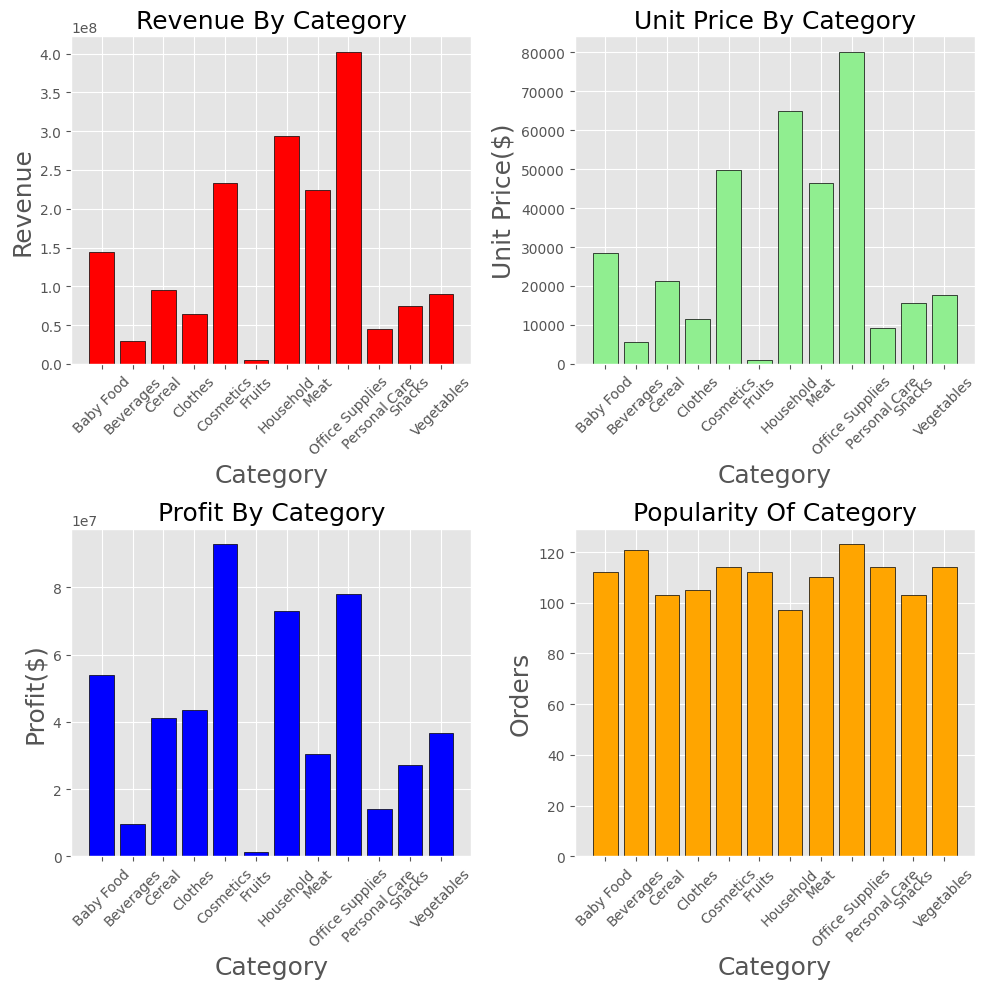

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (10, 10))
plt.style.use("ggplot")

#First subplot(Profit By Category)
ax[0, 0].bar(category_summary_category.index, category_summary_category["Revenue"], color = "red", edgecolor = "black")
ax[0, 0].set_title("Revenue By Category", fontsize = 18)
ax[0, 0].set_xlabel("Category", fontsize = 18)
ax[0, 0].set_ylabel("Revenue", fontsize = 18)
ax[0, 0].tick_params(axis='x', rotation=45)
#Second subplot(Unit Price By Category)
ax[0, 1].bar(category_summary_category.index, category_summary_category["Unit Price"], color = "lightgreen", edgecolor = "black")
ax[0, 1].set_title("Unit Price By Category", fontsize = 18)
ax[0, 1].set_xlabel("Category", fontsize = 18)
ax[0, 1].set_ylabel("Unit Price($)", fontsize = 18)
ax[0, 1].tick_params(axis = "x", rotation = 45)
#Third subplot(Revenue By Category)
ax[1, 0].bar(category_summary_category.index, category_summary_category["Profit"], color = "blue", edgecolor = "black")
ax[1, 0].set_title("Profit By Category", fontsize = 18)
ax[1, 0].set_xlabel("Category", fontsize = 18)
ax[1, 0].set_ylabel("Profit($)", fontsize = 18)
ax[1, 0].tick_params(axis = "x", rotation = 45)
#Fourth subplot(Orders by Category)
ax[1, 1].bar(category_summary_category.index, category_summary_category["Orders"], color = "orange", edgecolor = "black")
ax[1, 1].set_title("Popularity Of Category", fontsize = 18)
ax[1, 1].set_xlabel("Category", fontsize = 18)
ax[1, 1].set_ylabel("Orders", fontsize = 18)
ax[1, 1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()

**Аналіз в розрізі Країн**

In [ ]:
res_table["Revenue"] = res_table["Unit Price"] * res_table["Units Sold"]
category_summary_country = res_table.groupby("Country Name").agg({
    "Revenue": "sum",
    "Unit Price": "sum",
    "Profit": "sum",
    "Order ID": "count"
}).rename(columns={"Order ID": "Orders"})

print(category_summary_country)

                            Revenue  Unit Price       Profit  Orders
Country Name                                                        
Albania                 32224853.87     7085.98  10490706.02      21
Andorra                 48963657.01    10029.53  15863262.71      41
Armenia                 38059666.86     7432.49   9587874.48      30
Austria                 41045296.21     8186.19  12314040.02      32
Belarus                 38336759.57     6774.27  13483147.78      29
Belgium                 28161862.70     6630.07   8394441.48      27
Bosnia And Herzegovina  51376443.83    10927.30  13664591.48      37
Bulgaria                39918946.49    10008.52  10902418.85      32
Croatia                 30600724.94     6846.86   8422945.57      19
Cyprus                  33008851.50     6550.63  10032220.56      30
Czech Republic          53851075.68    10824.30  13746590.60      32
Denmark                 27476136.72     5586.60   9773366.42      29
Estonia                 23501631.7

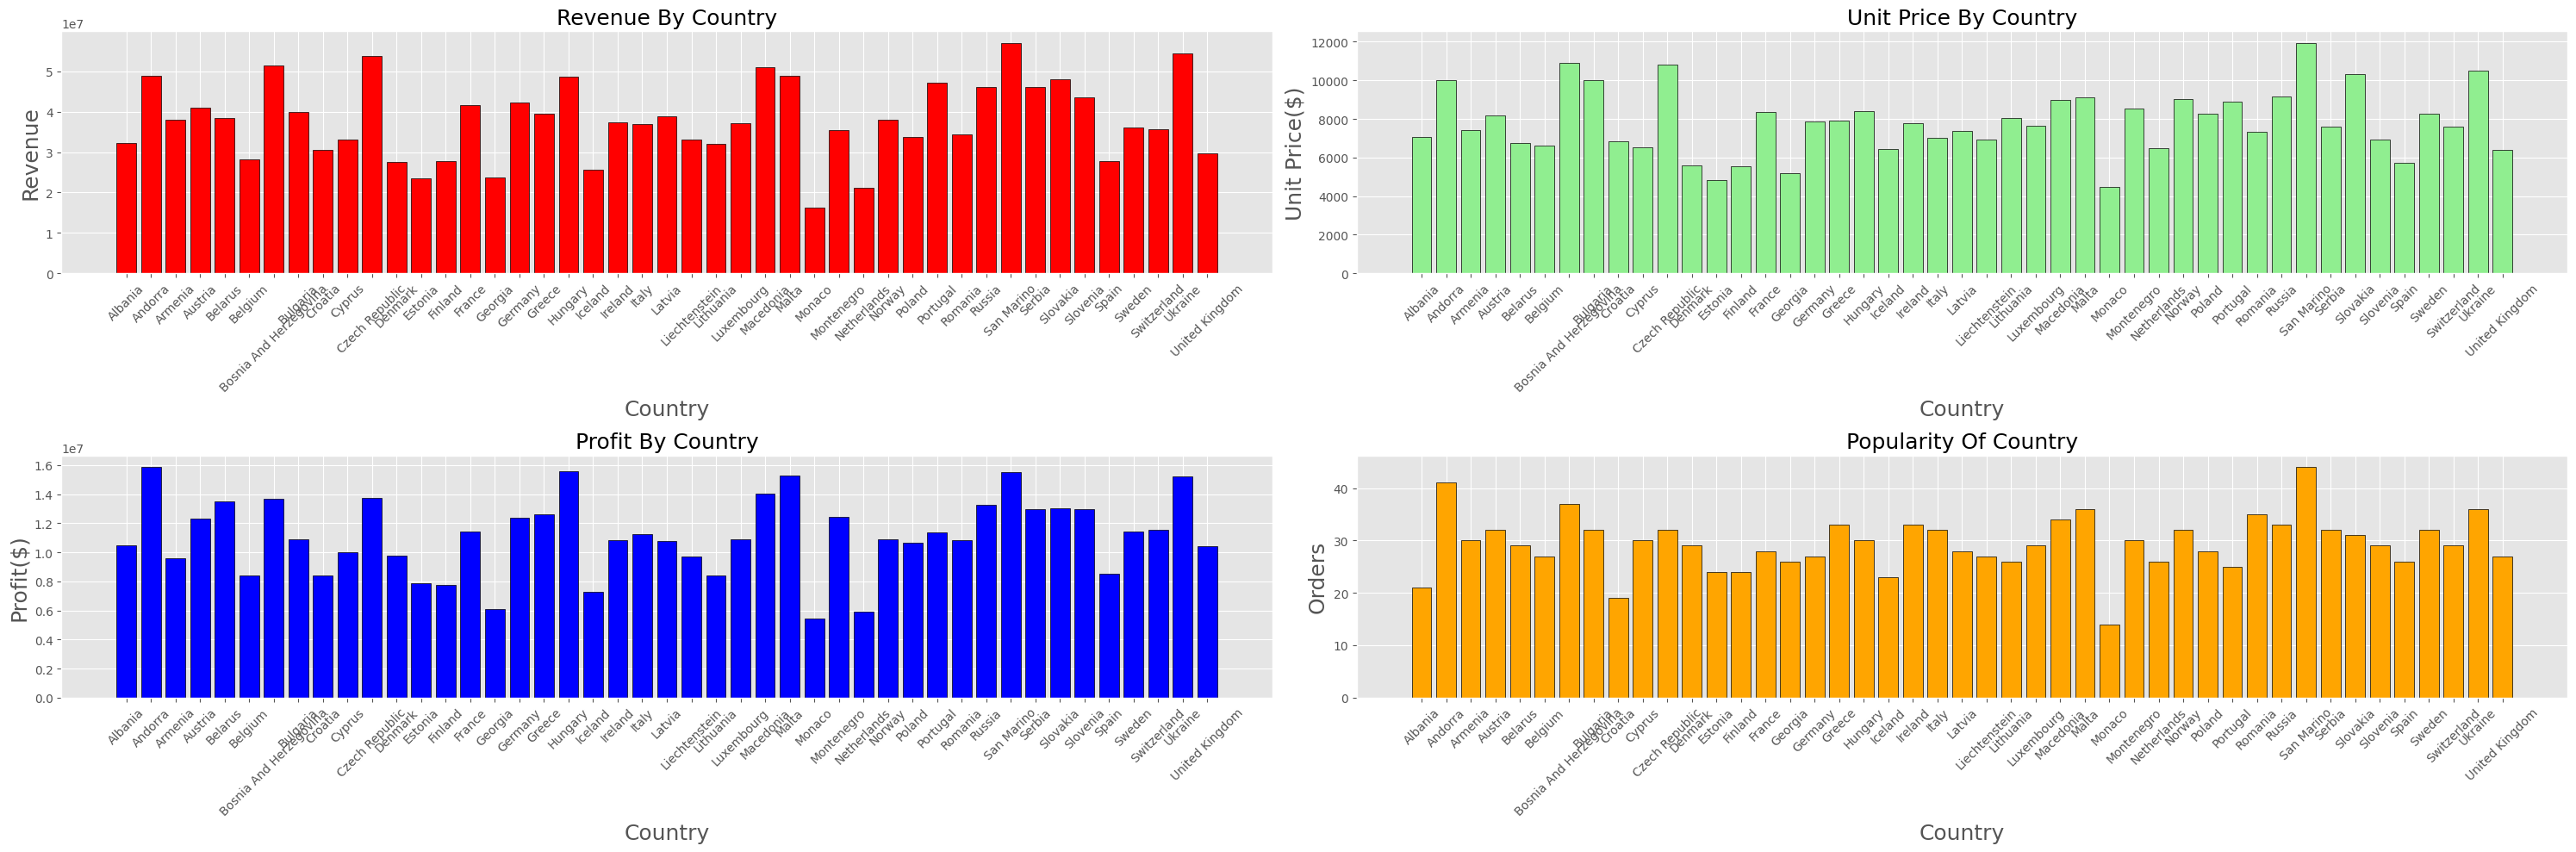

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (30, 10))
plt.style.use("ggplot")

#First subplot(Profit By Category)
ax[0, 0].bar(category_summary_country.index, category_summary_country["Revenue"], color = "red", edgecolor = "black")
ax[0, 0].set_title("Revenue By Country", fontsize = 18)
ax[0, 0].set_xlabel("Country", fontsize = 18)
ax[0, 0].set_ylabel("Revenue", fontsize = 18)
ax[0, 0].tick_params(axis='x', rotation=45)
#Second subplot(Unit Price By Category)
ax[0, 1].bar(category_summary_country.index, category_summary_country["Unit Price"], color = "lightgreen", edgecolor = "black")
ax[0, 1].set_title("Unit Price By Country", fontsize = 18)
ax[0, 1].set_xlabel("Country", fontsize = 18)
ax[0, 1].set_ylabel("Unit Price($)", fontsize = 18)
ax[0, 1].tick_params(axis = "x", rotation = 45)
#Third subplot(Revenue By Category)
ax[1, 0].bar(category_summary_country.index, category_summary_country["Profit"], color = "blue", edgecolor = "black")
ax[1, 0].set_title("Profit By Country", fontsize = 18)
ax[1, 0].set_xlabel("Country", fontsize = 18)
ax[1, 0].set_ylabel("Profit($)", fontsize = 18)
ax[1, 0].tick_params(axis = "x", rotation = 45)
#Fourth subplot(Orders by Category)
ax[1, 1].bar(category_summary_country.index, category_summary_country["Orders"], color = "orange", edgecolor = "black")
ax[1, 1].set_title("Popularity Of Country", fontsize = 18)
ax[1, 1].set_xlabel("Country", fontsize = 18)
ax[1, 1].set_ylabel("Orders", fontsize = 18)
ax[1, 1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()

**Аналіз в розрізі регіонів**

In [ ]:
res_table["Revenue"] = res_table["Unit Price"] * res_table["Units Sold"]
category_summary_region = res_table.groupby("Region").agg({
    "Revenue": "sum",
    "Unit Price": "sum",
    "Profit": "sum",
    "Order ID": "count"
}).rename(columns={"Order ID": "Orders"})

print(category_summary_region)

             Revenue  Unit Price        Profit  Orders
Region                                                
Asia    9.486943e+07    19154.14  2.571489e+07      86
Europe  1.607260e+09   332650.65  4.757196e+08    1242


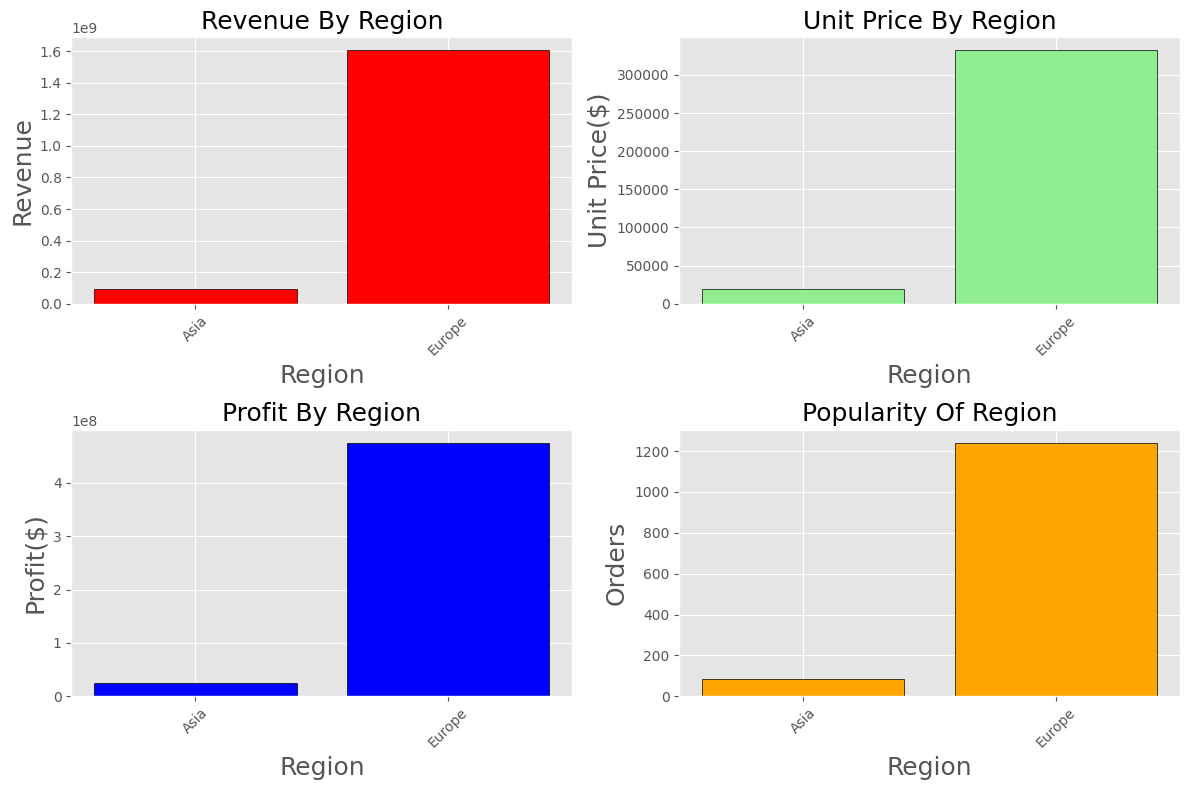

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))
plt.style.use("ggplot")

#First subplot(Profit By Category)
ax[0, 0].bar(category_summary_region.index, category_summary_region["Revenue"], color = "red", edgecolor = "black")
ax[0, 0].set_title("Revenue By Region", fontsize = 18)
ax[0, 0].set_xlabel("Region", fontsize = 18)
ax[0, 0].set_ylabel("Revenue", fontsize = 18)
ax[0, 0].tick_params(axis='x', rotation=45)
#Second subplot(Unit Price By Category)
ax[0, 1].bar(category_summary_region.index, category_summary_region["Unit Price"], color = "lightgreen", edgecolor = "black")
ax[0, 1].set_title("Unit Price By Region", fontsize = 18)
ax[0, 1].set_xlabel("Region", fontsize = 18)
ax[0, 1].set_ylabel("Unit Price($)", fontsize = 18)
ax[0, 1].tick_params(axis = "x", rotation = 45)
#Third subplot(Revenue By Category)
ax[1, 0].bar(category_summary_region.index, category_summary_region["Profit"], color = "blue", edgecolor = "black")
ax[1, 0].set_title("Profit By Region", fontsize = 18)
ax[1, 0].set_xlabel("Region", fontsize = 18)
ax[1, 0].set_ylabel("Profit($)", fontsize = 18)
ax[1, 0].tick_params(axis = "x", rotation = 45)
#Fourth subplot(Orders by Category)
ax[1, 1].bar(category_summary_region.index, category_summary_region["Orders"], color = "orange", edgecolor = "black")
ax[1, 1].set_title("Popularity Of Region", fontsize = 18)
ax[1, 1].set_xlabel("Region", fontsize = 18)
ax[1, 1].set_ylabel("Orders", fontsize = 18)
ax[1, 1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()

**Аналіз в розрізі каналів продажу**

In [ ]:
res_table["Revenue"] = res_table["Unit Price"] * res_table["Units Sold"]
category_summary_channel = res_table.groupby("Sales Channel").agg({
    "Revenue": "sum",
    "Unit Price": "sum",
    "Profit": "sum",
    "Order ID": "count"
}).rename(columns={"Order ID": "Orders"})

print(category_summary_channel)

                    Revenue  Unit Price        Profit  Orders
Sales Channel                                                
Offline        8.717606e+08   174916.57  2.534665e+08     665
Online         8.303688e+08   176888.22  2.479679e+08     663


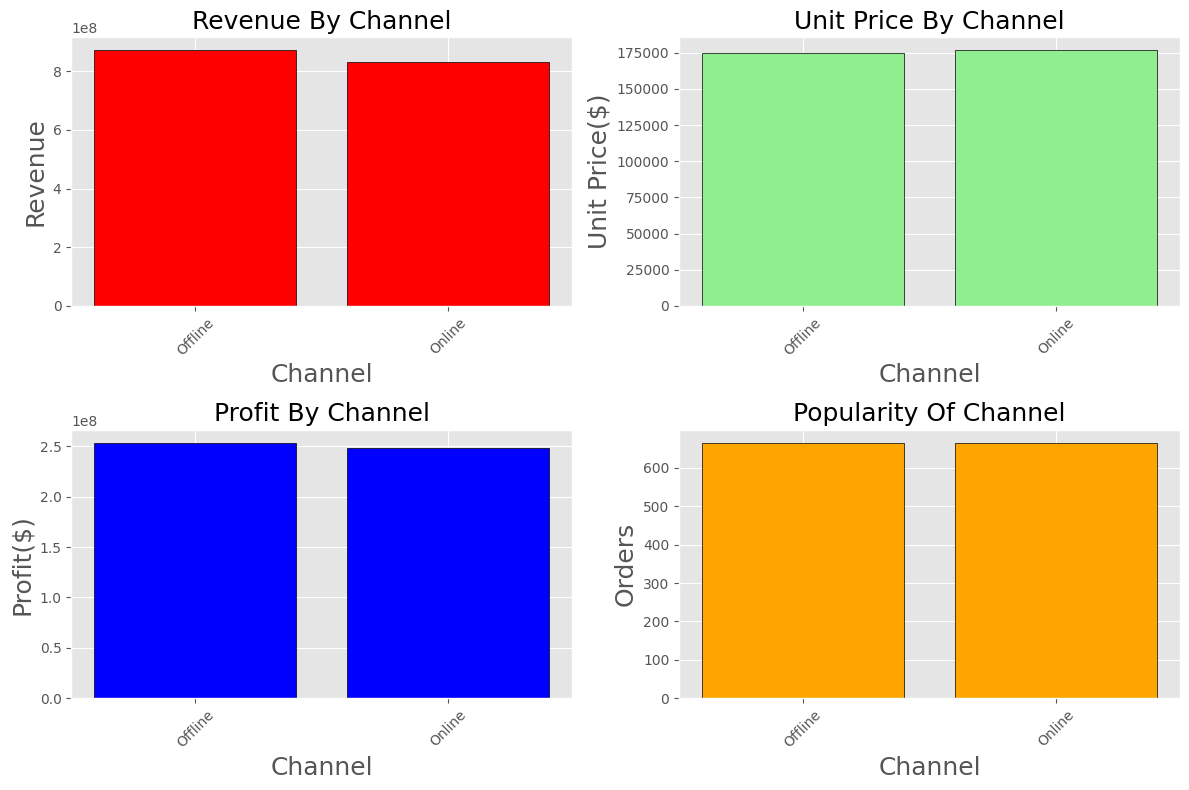

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))
plt.style.use("ggplot")

#First subplot(Profit By Category)
ax[0, 0].bar(category_summary_channel.index, category_summary_channel["Revenue"], color = "red", edgecolor = "black")
ax[0, 0].set_title("Revenue By Channel", fontsize = 18)
ax[0, 0].set_xlabel("Channel", fontsize = 18)
ax[0, 0].set_ylabel("Revenue", fontsize = 18)
ax[0, 0].tick_params(axis='x', rotation=45)
#Second subplot(Unit Price By Category)
ax[0, 1].bar(category_summary_channel.index, category_summary_channel["Unit Price"], color = "lightgreen", edgecolor = "black")
ax[0, 1].set_title("Unit Price By Channel", fontsize = 18)
ax[0, 1].set_xlabel("Channel", fontsize = 18)
ax[0, 1].set_ylabel("Unit Price($)", fontsize = 18)
ax[0, 1].tick_params(axis = "x", rotation = 45)
#Third subplot(Revenue By Category)
ax[1, 0].bar(category_summary_channel.index, category_summary_channel["Profit"], color = "blue", edgecolor = "black")
ax[1, 0].set_title("Profit By Channel", fontsize = 18)
ax[1, 0].set_xlabel("Channel", fontsize = 18)
ax[1, 0].set_ylabel("Profit($)", fontsize = 18)
ax[1, 0].tick_params(axis = "x", rotation = 45)
#Fourth subplot(Orders by Category)
ax[1, 1].bar(category_summary_channel.index, category_summary_channel["Orders"], color = "orange", edgecolor = "black")
ax[1, 1].set_title("Popularity Of Channel", fontsize = 18)
ax[1, 1].set_xlabel("Channel", fontsize = 18)
ax[1, 1].set_ylabel("Orders", fontsize = 18)
ax[1, 1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()

**Аналіз інтервалу часу між замовленням та його відвантаженням у розрізі категорій, країн та регіонів**

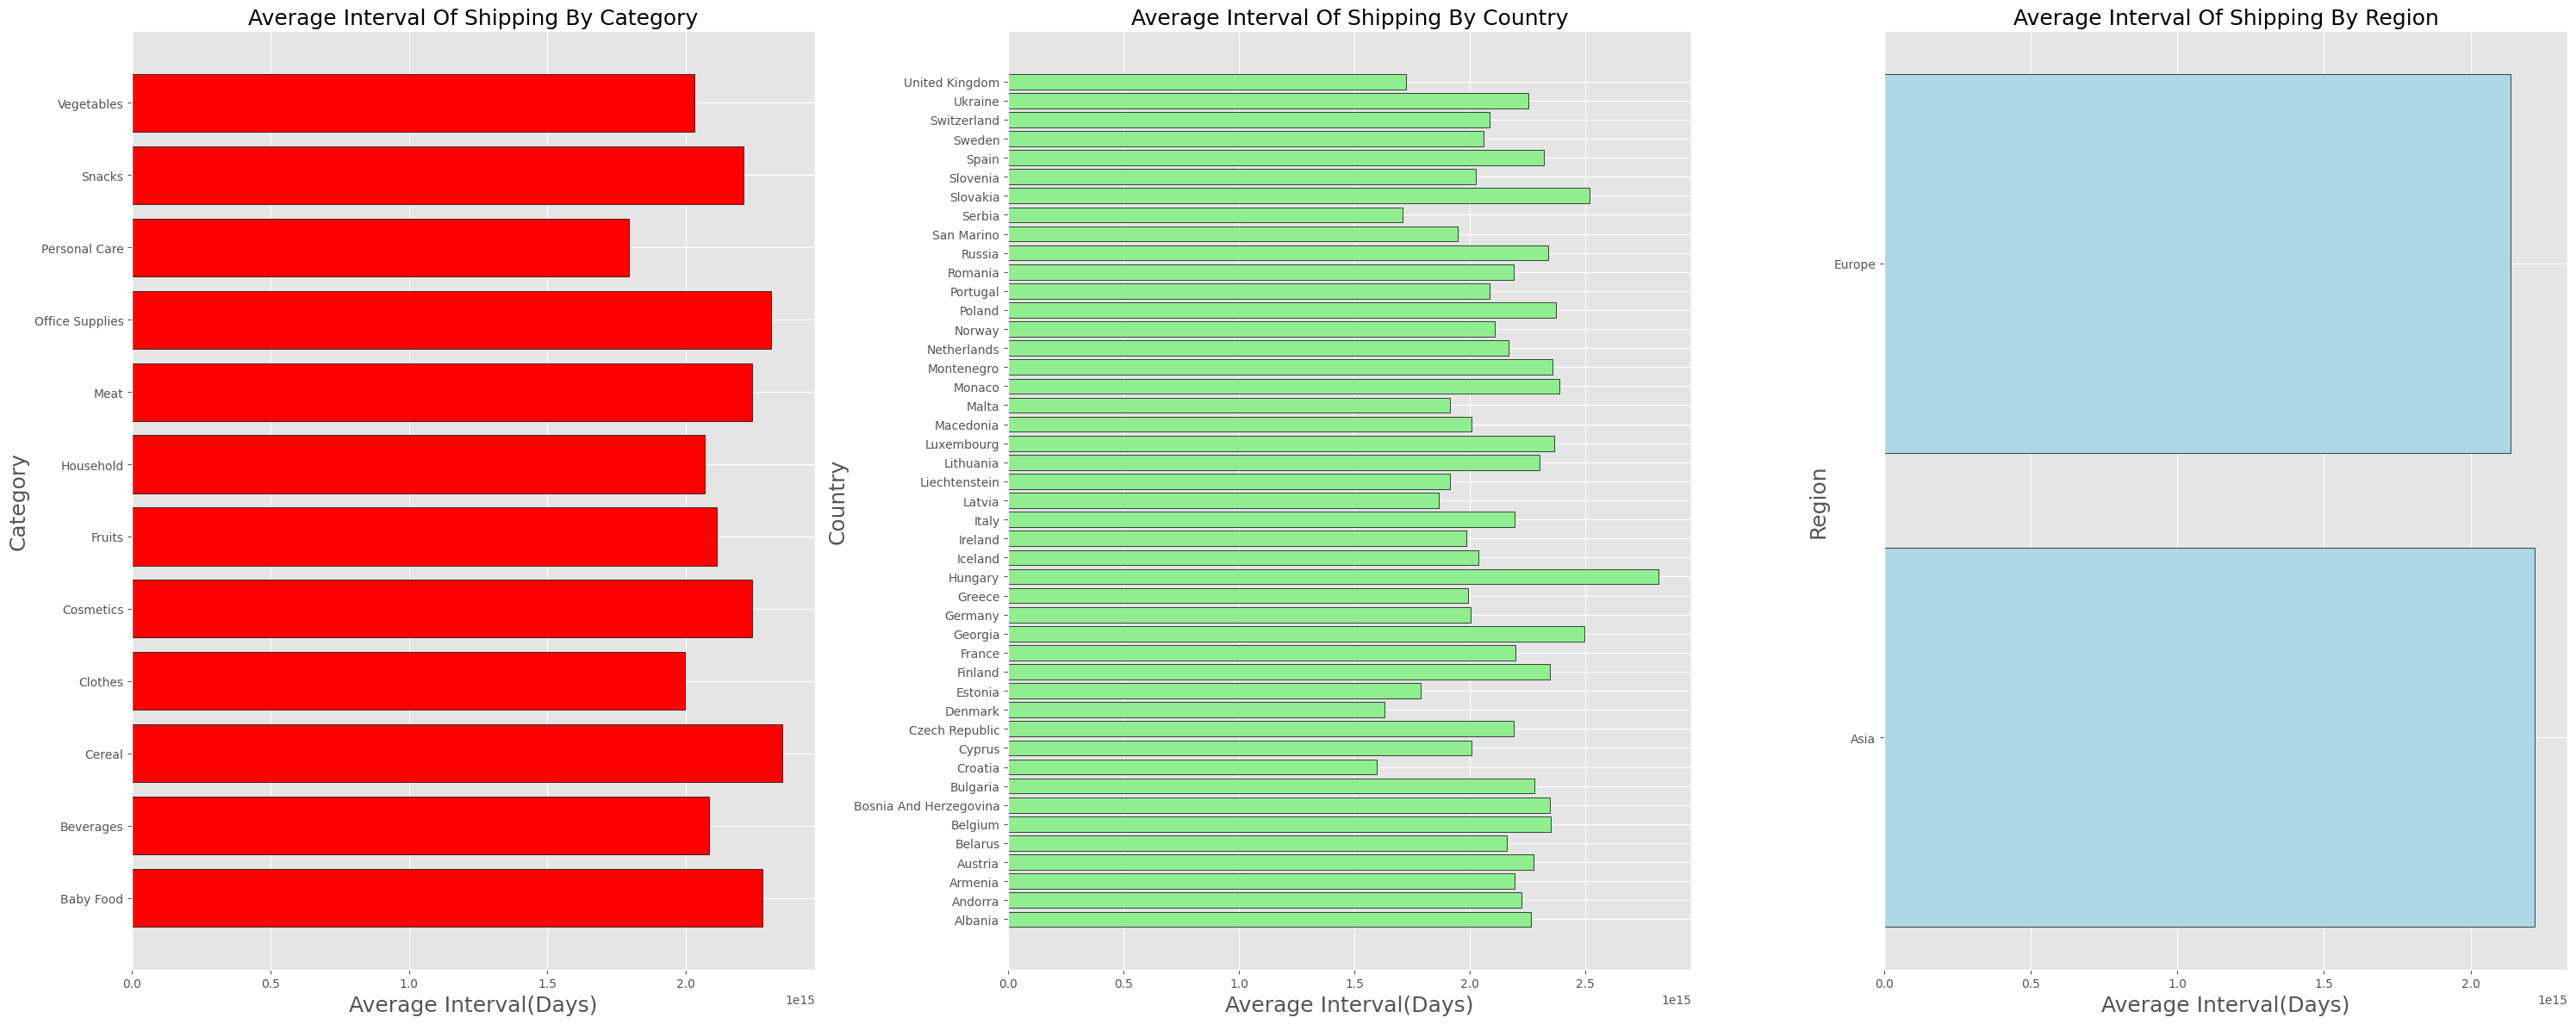

In [ ]:
res_table["Interval"] = res_table["Ship Date"] - res_table["Order Date"]

shipping_mean_category = res_table.groupby("Product Category", observed = False)["Interval"].mean()
shipping_mean_country = res_table.groupby("Country Name", observed = False)["Interval"].mean()
shipping_mean_region = res_table.groupby("Region", observed = False)["Interval"].mean()

fig, ax = plt.subplots(1, 3, figsize = (30, 12))

#First subplot(Interval By Category)
ax[0].barh(shipping_mean_category.index, shipping_mean_category.values, color = "red", edgecolor = "black")
ax[0].set_title("Average Interval Of Shipping By Category", fontsize = 18)
ax[0].set_xlabel("Average Interval(Days)", fontsize = 18)
ax[0].set_ylabel("Category", fontsize = 18)

#Second subplot(Interval By Country)
ax[1].barh(shipping_mean_country.index, shipping_mean_country.values, color = "lightgreen", edgecolor = "black")
ax[1].set_title("Average Interval Of Shipping By Country", fontsize = 18)
ax[1].set_xlabel("Average Interval(Days)", fontsize = 18)
ax[1].set_ylabel("Country", fontsize = 18)

#Third subplot(Interval By Region)
ax[2].barh(shipping_mean_region.index, shipping_mean_region.values, color = "lightblue", edgecolor = "black")
ax[2].set_title("Average Interval Of Shipping By Region", fontsize = 18)
ax[2].set_xlabel("Average Interval(Days)", fontsize = 18)
ax[2].set_ylabel("Region", fontsize = 18)

plt.tight_layout()

**Аналіз прибутку від часу, необхідного на відвантаження товару**

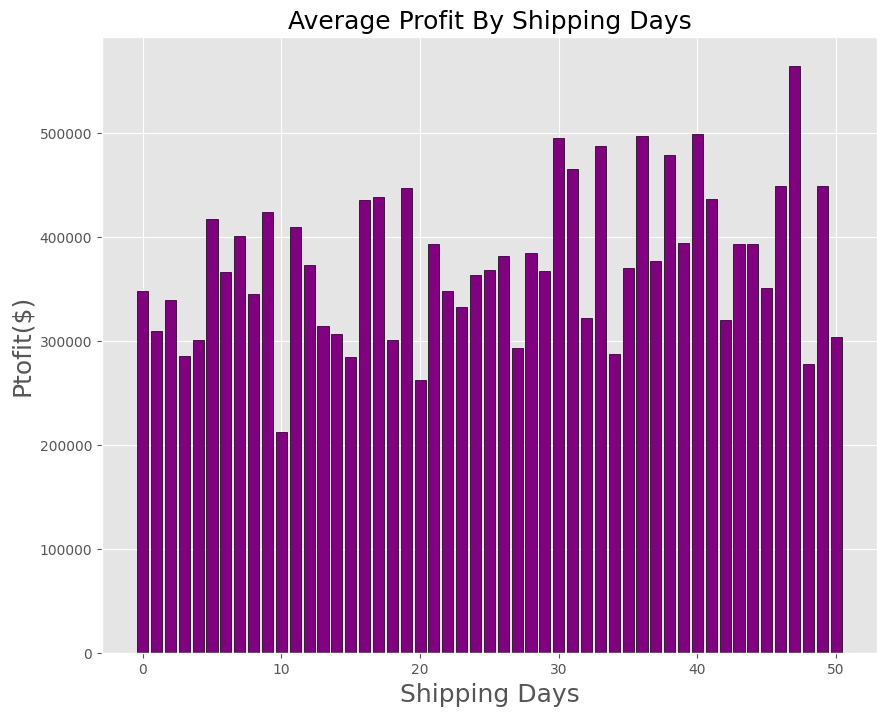

In [ ]:
res_table["Shipping Days"] = (res_table["Ship Date"] - res_table["Order Date"]).dt.days

profit_by_shipping = res_table.groupby("Shipping Days")["Profit"].mean()

plt.figure(figsize = (10, 8))
plt.bar(profit_by_shipping.index, profit_by_shipping.values, color = "purple", edgecolor = "black")
plt.title("Average Profit By Shipping Days", fontsize = 18)
plt.xlabel("Shipping Days", fontsize = 18)
plt.ylabel("Ptofit($)", fontsize = 18)
plt.show()

**Аналіз динаміки продажів(у часі) у розрізі категорій, країн та регіонів**

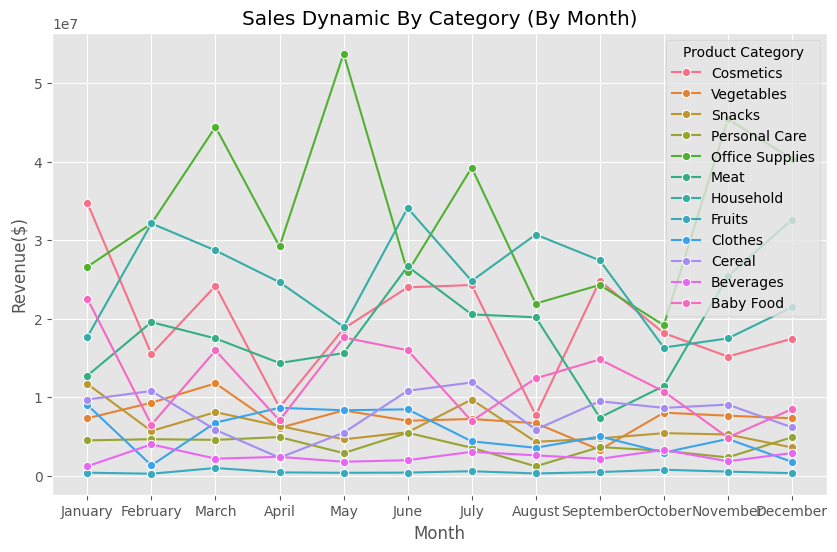

In [ ]:
res_table["Month"] = res_table["Order Date"].dt.month_name()

dynamic_revenue_by_category = res_table.groupby(["Month", "Product Category"])["Revenue"].sum().reset_index()

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

dynamic_revenue_by_category["Month"] = pd.Categorical(dynamic_revenue_by_category["Month"], categories = month_order, ordered = True)
res_table_sorted = dynamic_revenue_by_category.sort_values("Month")

plt.figure(figsize = (10, 6))
sns.lineplot(data = res_table_sorted, x = "Month", y = "Revenue", hue = "Product Category", marker = "o")
plt.title("Sales Dynamic By Category (By Month)")
plt.xlabel("Month")
plt.ylabel("Revenue($)")
plt.show()

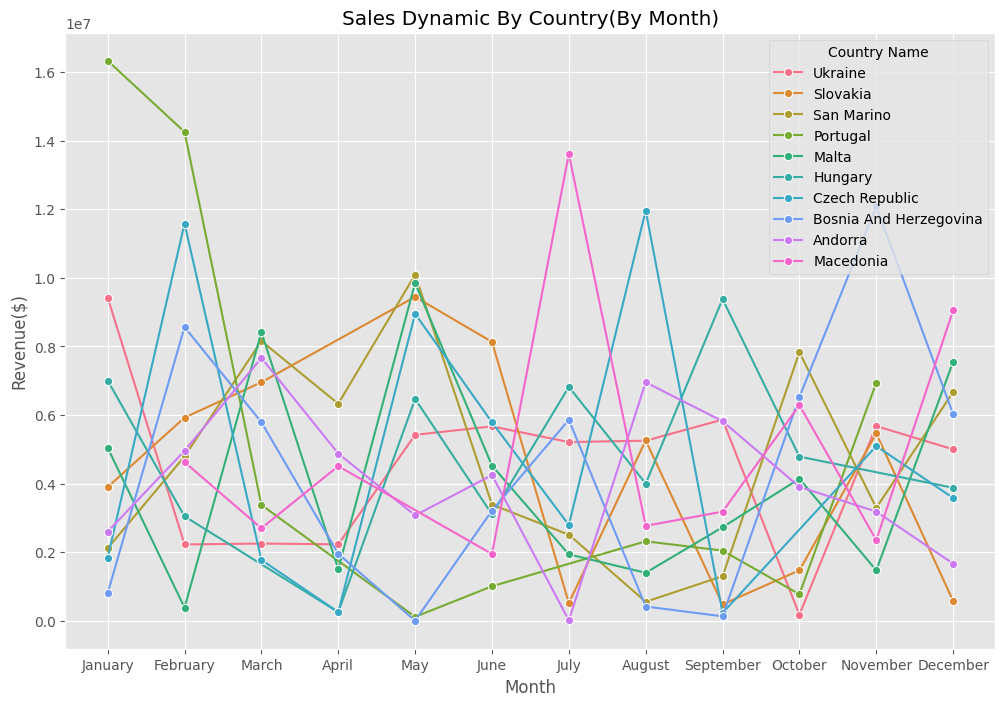

In [ ]:
top_countries = res_table.groupby("Country Name")["Revenue"].sum().nlargest(10).index

country_sales_filtered = res_table[res_table["Country Name"].isin(top_countries)]

country_sales_grouped = country_sales_filtered.groupby(["Month", "Country Name"])["Revenue"].sum().reset_index()

country_sales_grouped["Month"] = pd.Categorical(country_sales_grouped["Month"], categories = month_order, ordered=True)

country_sales_grouped = country_sales_grouped.sort_values("Month")

plt.figure(figsize = (12, 8))
sns.lineplot(data = country_sales_grouped, x = "Month", y = "Revenue", hue = "Country Name", marker = "o")
plt.title("Sales Dynamic By Country(By Month)")
plt.xlabel("Month")
plt.ylabel("Revenue($)")
plt.show()

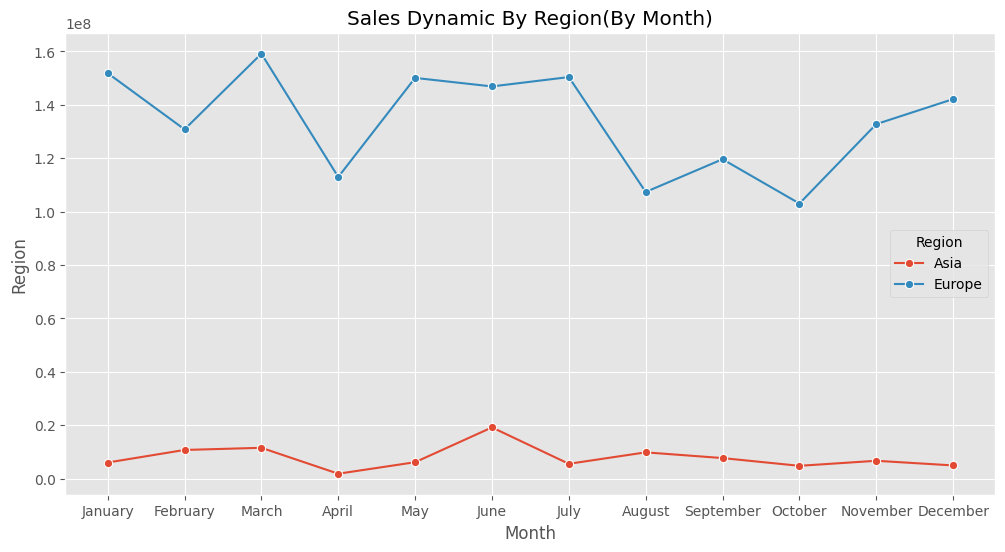

In [ ]:
region_dynamic = res_table.groupby(["Month", "Region"])["Revenue"].sum().reset_index()
region_dynamic["Month"] = pd.Categorical(region_dynamic["Month"], categories = month_order, ordered = True)

region_dynamic_sorted = region_dynamic.sort_values("Month")

plt.figure(figsize = (12, 6))
sns.lineplot(data = region_dynamic_sorted, x = "Month", y = "Revenue", hue = "Region", marker = "o")
plt.title("Sales Dynamic By Region(By Month)")
plt.xlabel("Month")
plt.ylabel("Region")
plt.show()

#Аналіз
#Data overview
Було завантажено три датасети:

Events – інформація про замовлення:
Дата замовлення та отримання (Order Date, Ship Date)
Пріоритет замовлення (Order Priority)
Код країни (Country Code)
Код товару (Product ID)
Канал замовлення (Sales Channel)

Дані про продажі: кількість (Units Sold), ціна за одиницю (Unit Price), собівартість (Unit Cost)
Countries – інформація про країни:
Повна назва країни (Country Name)
Скорочені назви (alpha-2, alpha-3)
Регіон (Region) та під-регіон (Sub-region)
Products – інформація про товари:
Категорія замовленого товару (Product Category)
З’єднання таблиць:

Events + Countries → за Country Code (events) та alpha-3 (countries)
Events + Products → за Product ID (events) та item_type (products)
Data Cleaning
Пропущені значення
Таблиця events мала 6.17% пропусків у полі Country Code.

Причина: замовник міг не вказувати країну.
Рішення: заповнення методом ffill(). У інших таблицях відсоток пропусків незначний → рядки видалені.
Типи даних
Order Date та Ship Date → перетворені на тип datetime
Units Sold → перетворено з float на int
Дублікати
Перевірено на дублікати з урахуванням пробілів та регістру → видалено
Аномалії у таблиці events
Від’ємні, нульові або надто великі значення для кількості → відсутні
Дата отримання раніше дати замовлення або вихід за межі періоду (2010-01-01 – 2017-07-23) → відсутні
Коди країн або продуктів, яких немає у відповідних таблицях → відсутні
Таблиці countries та products
Аномалій немає, окрім потенційних дублікатів та пропусків, які вже перевірено
Data analysis and visualization
Об’єднання таблиць
Використано left join до таблиці events
Змінено назви колонок:
"name" → "Country Name"
"region" → "Region"
"sub-region" → "Sub-region"
"item_type" → "Product Category"
Видалено непотрібні стовпчики:
"Country Code"
"Product ID"
"alpha-2
Обчислення ключових метрик
Загальна кількість замовлень: 1,328
Загальний прибуток: 501,434,459
Загальна кількість охоплених країн: 45
Загальна кількість проданих товарів: 6,576,524
Середня вартість замовлення: 76.25
Аналіз у розрізі категорій, країн, регіонів та каналів продажу
Було проаналізовано основні метрики:

Revenue (дохід)

Unit Price (ціна за одиницю)

Profit (прибуток)

Orders (кількість замовлень)

Аналіз проводився у розрізі:

Категорій товарів

Країн

Регіонів

Каналів продажу (онлайн/офлайн)

Висновки за категоріями

Найбільш прибутковою категорією є "Cosmetics", незважаючи на те, що вона не є найпопулярнішою за кількістю замовлень.
Найбільші доходи приносять категорії "Office Supplies" та "Household".
Найпопулярнішими категоріями є "Office Supplies" та "Beverages", що вказує на стабільний попит на ці товари.
Висновки за країнами

Найбільш прибутковими країнами є Андорра, Угорщина та Сан-Марино.
Найбільші доходи приносять Сан-Марино та Україна.
Найпопулярнішими країнами є Сан-Марино та Андорра, що вказує на стабільний попит на товари в цих країнах.
Висновки за регіонами

Загалом, аналіз показує, що Європа є ключовим ринком для бізнесу за всіма показниками: доходами, прибутком, сумарною ціною та кількістю замовлень. Її показники значно перевершують показники азіатського регіону, що робить Європу пріоритетним напрямком для подальшого розвитку.

Висновки за каналами продажу

Загалом, аналіз показує, що офлайн-канал є основним джерелом доходів і прибутку, а також має більшу кількість замовлень. Водночас, онлайн-канал демонструє, що в ньому реалізуються товари з трохи вищою середньою ціною. Це свідчить про те, що обидва канали є важливими для бізнесу, але офлайн-канал наразі є більш продуктивним.

Аналіз інтервалу часу між замовленням та відвантаженням.
Було проведено аналіз тривалості доставки (Shipping Days) у розрізі:

Категорій товарів
Країн
Регіонів
Висновок за категоріями

Найшвидша доставка спостерігається для категорії "Personal Care" з середнім часом доставки приблизно 20.76 дня.
Найдовший час доставки мають товари з категорії "Cereal", що становить близько 27.18 дня.
Більшість категорій товарів мають середній час доставки в межах 23-26 днів.
Висновок за країнами

Найшвидша доставка спостерігається в Хорватії та Данії, з середнім часом доставки приблизно 18.47 та 18.86 дня відповідно.
Найдовший час доставки мають замовлення, що відправляються до Угорщини, з середнім часом доставки близько 32.60 дня.
Більшість країн мають середній час доставки в межах 23-27 днів.
Висновок за регіонами

Загалом, аналіз показує, що за регіонами, середня тривалість доставки в Азії трохи більша ніж у Європі.

Аналыз залежносты прибутка від часу, необхідного на відвантаження товару
Аналіз показує, що немає прямої залежності між прибутком і часом, необхідним для відвантаження товару. Незважаючи на коливання прибутку, ці зміни не пов'язані з тривалістю доставки. Це означає, що, оптимізація часу відвантаження сама по собі не призведе до збільшення прибутку.

Аналіз продажів (у часі) у розрізі категорій товарів, країн, регіонів
За категоріями

Основними драйверами виручки є Office Supplies та Meat, саме вони формують більшість доходів.
У категорій Cosmetics, Baby Food, Beverages спостерігаються значні коливання, що може свідчити про чутливість попиту до сезонності чи маркетингових акцій.
Низка категорій (Fruits, Household) приносить дуже мало доходу, що може свідчити про вузький попит або недостатнє охоплення ринку.
За країнами

Для дослідження було відібрано топ-10 країн за обсягом виручки, оскільки якщо додати на графік усі країни, він буде перенавантажений і важко інтерпретуємий.

Лідерами за обсягами продажів виступають Португалія та Чехія — саме в них спостерігаються пікові значення виручки у різні місяці.
У Словаччини та Сан-Марино виручка розподілена більш рівномірно впродовж року, без різких стрибків.
У низки країн (наприклад, Андорра, Боснія і Герцеговина, Македонія) простежуються сезонні коливання з помітними піками в окремі місяці.
Україна та Угорщина демонструють середній рівень доходів, але з доволі частими коливаннями.
За регіонами:

Продажі в Європі демонструють значну стабільність протягом року, з найвищим піком у березні та січні. Спостерігається помітне падіння доходів у серпні та жовтні.
Продажі в Азії показують значно менші обсяги доходів порівняно з Європою, що може вказувати на менший ринок або інші фактори, що впливають на продажі.
Найвищий дохід в Азії спостерігався у червні, тоді як найнижчий – у квітні та жовтні.
Аналіз продажів товарів за днями тижня
Найвищі продажі зафіксовано в понеділок та четвер. Це може свідчити про активність клієнтів на початку робочого тижня, що робить ці дні ключовими для бізнесу.
Найнижчі продажі припадають на середу та вівторок, що робить їх потенційними цілями для маркетингових акцій.
Вихідні показують стабільно високі продажі, які знаходяться на рівні середніх показників буднів.